<a href="https://colab.research.google.com/github/6dsfg56sfg5/ML/blob/stuts/S22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
mtcars=pd.read_csv("mtcars.csv")

In [6]:
mtcars.isna().sum().sum()

np.int64(0)

In [9]:
dat = mtcars.copy()
dat.loc[[1, 3, 9], 'mpg'] = np.nan
print(dat.isna().sum().sum())
print(np.where(dat.isna()))
print(dat['mpg'].iloc[[1, 3, 9]])


3
(array([1, 3, 9]), array([1, 1, 1]))
1   NaN
3   NaN
9   NaN
Name: mpg, dtype: float64


In [10]:
dat1 = dat.dropna()

In [11]:
from sklearn.impute import SimpleImputer
imputer_mean = SimpleImputer(strategy='mean')
G1 = imputer_mean.fit_transform(dat[['mpg']]).flatten()
imputer_median = SimpleImputer(strategy='median')
G2 = imputer_median.fit_transform(dat[['mpg']]).flatten()
imputer_constant = SimpleImputer(strategy='constant', fill_value=13)
G3 = imputer_constant.fit_transform(dat[['mpg']]).flatten()


In [12]:
print(pd.Series(dat['mpg']).describe())
print(pd.Series(G1).describe())
print(pd.Series(G2).describe())
print(pd.Series(G3).describe())

count    29.000000
mean     20.044828
std       6.332038
min      10.400000
25%      15.200000
50%      18.700000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64
count    32.000000
mean     20.044828
std       6.017854
min      10.400000
25%      15.425000
50%      19.450000
75%      22.800000
max      33.900000
dtype: float64
count    32.000000
mean     19.918750
std       6.031019
min      10.400000
25%      15.425000
50%      18.700000
75%      22.800000
max      33.900000
dtype: float64
count    32.000000
mean     19.384375
std       6.369236
min      10.400000
25%      14.925000
50%      17.950000
75%      22.800000
max      33.900000
dtype: float64


In [14]:
x = [
    4.27296076175273, 4.3253044335640, 4.55202839528403,
    4.33285651824668, 4.0128340310945, 4.07155452370293,
    4.04113475664987, 2.7753693269563, 2.49186430883914,
    2.39823431758359, 2.3789955162936, 2.14825292752989,
    2.19583315284264, 2.1947104626036, 2.14216783486566,
    2.28399128121205, 2.3048696257819, 2.23703873535593,
    2.28669486582313, 2.4163169738317, 2.03782758779637,
    2.61237703056071, 3.47620332697605
]

y = [
    9.097731, 9.512591, 9.740439, 9.910364, 9.865059, 9.935519,
    9.972640, 9.920197, 10.367693, 10.680861, 10.999012, 11.246248,
    10.532816, 11.144033, 11.261961, 11.400160, 11.080695, 11.173922,
    11.506877, 11.105483, 10.807685, 6.489205, 4.882802
]


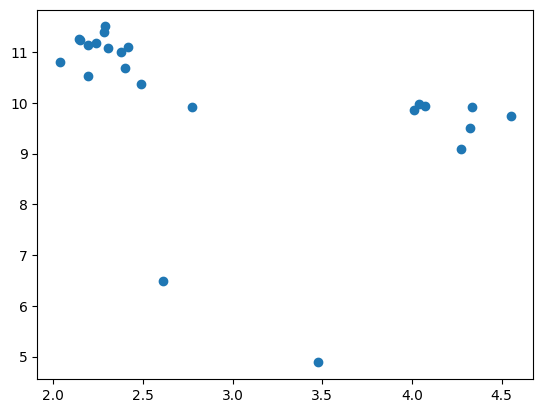

In [15]:
plt.scatter(x, y)
plt.show()


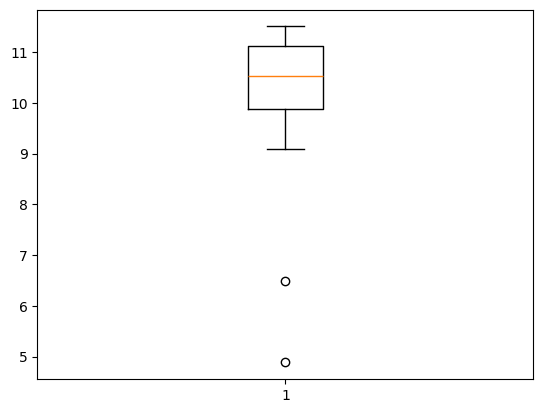

In [16]:
plt.boxplot(y)
plt.show()


In [17]:
q1 = np.quantile(y, 0.25)
q3 = np.quantile(y, 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = [val for val in y if val < lower_bound or val > upper_bound]
ind = [i for i, val in enumerate(y) if val in outliers]


In [18]:
outlier_df = pd.DataFrame({'x': [x[i] for i in ind], 'y': [y[i] for i in ind]})

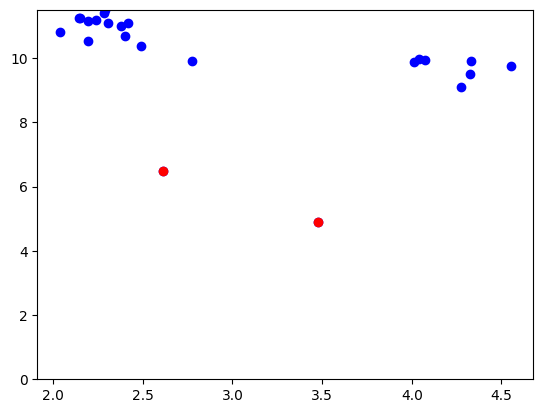

In [19]:
plt.scatter(x, y, color='blue', marker='o')
plt.scatter(outlier_df['x'], outlier_df['y'], color='red', marker='o')
plt.ylim(0, max(y))
plt.show()


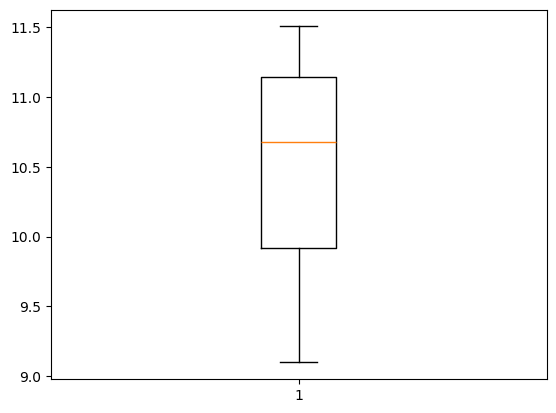

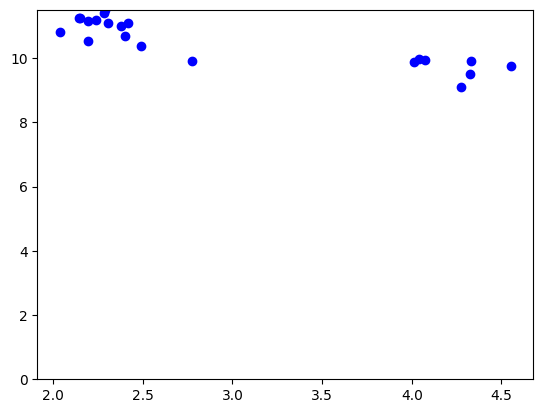

In [20]:
x_clean = [x[i] for i in range(len(x)) if i not in ind]
y_clean = [y[i] for i in range(len(y)) if i not in ind]
plt.boxplot(y_clean)
plt.show()
plt.scatter(x_clean, y_clean, color='blue', marker='o')
plt.ylim(0, max(y_clean))
plt.show()


In [23]:
!pip install outlier-utils
from outliers import smirnov_grubbs as grubbs
data = [5, 14, 15, 15, 14, 13, 19, 17, 16, 20, 22, 8, 21, 28, 11, 9, 29, 40]
result = grubbs.test(data, alpha=0.05)
print(f"Выбросы: { set(data)-set(result) }")


Выбросы: {40}


In [26]:
result_opposite = grubbs.min_test(data, alpha=0.05)
print(f"Минимальный выброс: { set(data)-set(result_opposite) }")

Минимальный выброс: set()


In [27]:
!pip install scipy

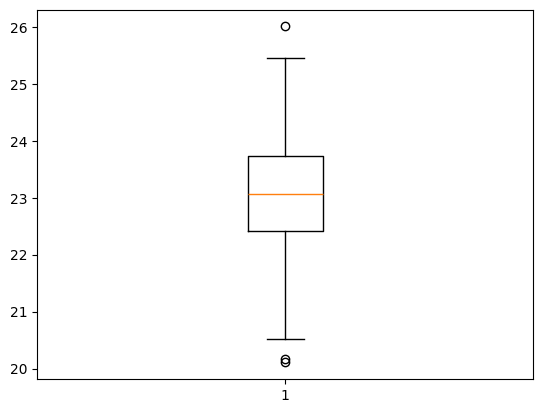

count    500.000000
mean      23.056361
std        0.993736
min       20.107488
25%       22.415226
50%       23.058109
75%       23.724814
max       26.005413
dtype: float64
Нижняя граница: 21.09497630694613
Верхняя граница: 25.02124103520959


In [28]:
from scipy.stats import median_abs_deviation

x = np.random.normal(23, 1, 500)

plt.boxplot(x)
plt.show()

print(pd.Series(x).describe())

mad = median_abs_deviation(x)
median_val = np.median(x)

lower_bound = median_val - 3 * mad
upper_bound = median_val + 3 * mad

print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")


In [29]:
outlier_ind = np.where((x < lower_bound) | (x > upper_bound))[0]
print(f"Индексы выбросов: {outlier_ind}")

print(f"Значение выброса с индексом {outlier_ind[0]}: {x[outlier_ind[0]]}")
print(f"Значение выброса с индексом {outlier_ind[-1]}: {x[outlier_ind[-1]]}")


Индексы выбросов: [  3  15  41  56  86 126 157 181 206 244 260 302 305 313 333 350 391 409
 423 447 454 455 459 467 470 477 493]
Значение выброса с индексом 3: 20.915846811199664
Значение выброса с индексом 493: 25.16923914688056


In [30]:
data = pd.read_csv("InsectSprays.csv")

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72 non-null     int64 
 1   count       72 non-null     int64 
 2   spray       72 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.8+ KB


In [32]:
data

,Unnamed: 0,count,spray
0,1,10,A
1,2,7,A
2,3,20,A
3,4,14,A
4,5,14,A
...,...,...,...
67,68,10,F
68,69,26,F
69,70,26,F
70,71,24,F


In [33]:
data.isna().sum().sum()

np.int64(0)

{'whiskers': [<matplotlib.lines.Line2D at 0x7e8b0b631d10>,
 'caps': [<matplotlib.lines.Line2D at 0x7e8b0b631f90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e8b0b631bd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7e8b0b632210>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e8b0b632350>],
 'means': []}

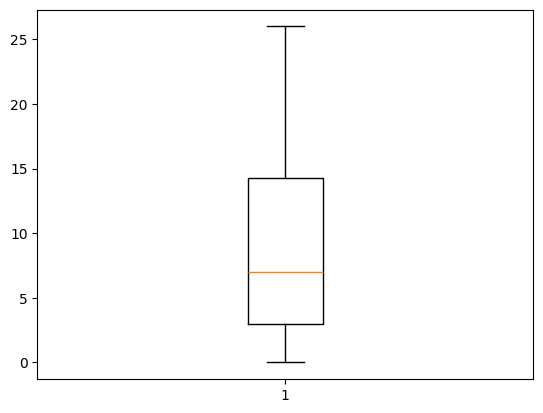

In [41]:
plt.boxplot(data['count'])

<BarContainer object of 72 artists>

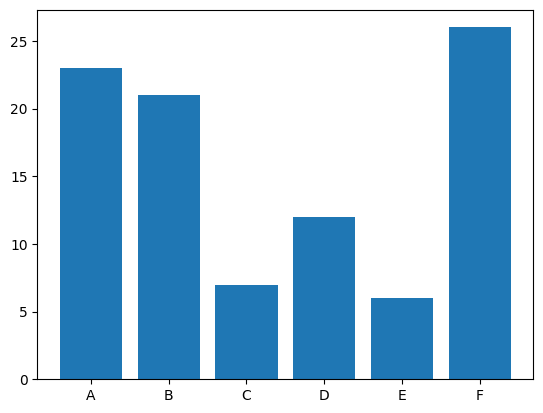

In [48]:
plt.bar(data['spray'],data['count'])

In [56]:
print(data.groupby('spray')['count'].describe())

       count       mean       std  min    25%   50%    75%   max
spray                                                           
A       12.0  14.500000  4.719399  7.0  11.50  14.0  17.75  23.0
B       12.0  15.333333  4.271115  7.0  12.50  16.5  17.50  21.0
C       12.0   2.083333  1.975225  0.0   1.00   1.5   3.00   7.0
D       12.0   4.916667  2.503028  2.0   3.75   5.0   5.00  12.0
E       12.0   3.500000  1.732051  1.0   2.75   3.0   5.00   6.0
F       12.0  16.666667  6.213378  9.0  12.50  15.0  22.50  26.0


<Axes: >

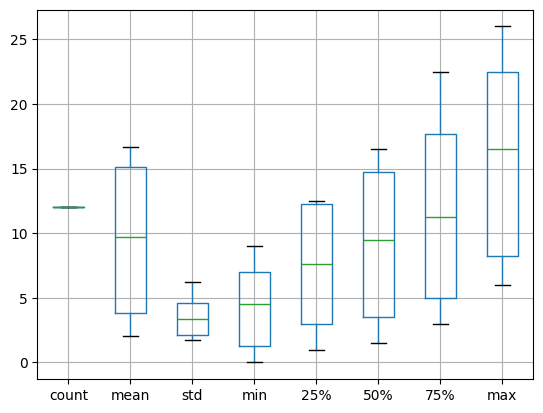

In [64]:
data.groupby('spray')['count'].describe().boxplot()

<Axes: title={'center': 'count'}, xlabel='spray'>

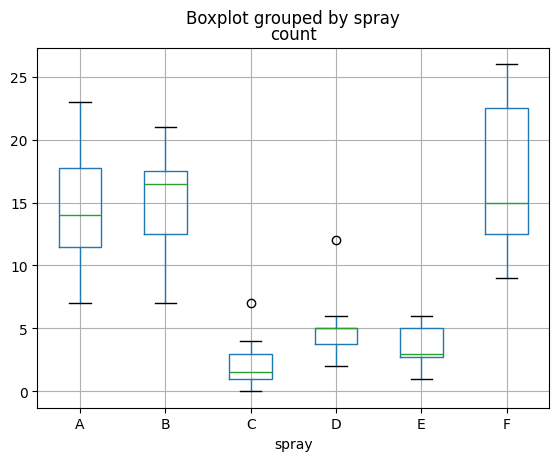

In [68]:
data.boxplot(column='count', by='spray')

Всего по 1 выбросу в C и D группах!